<a href="https://colab.research.google.com/github/kamil0sek1/kursAI/blob/main/lekcja_16_knn_irysy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
#sekcja1 importy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import numpy as np
import math


In [26]:
#sekcja 2
dane = sns.load_dataset("iris")

# print("\nPierwsze 10 rekordów: ")
# print(dane.head(10))

cechy = dane.columns.drop("species")
gatunki = dane["species"].unique()

print("\nOpis zbioru danych Iris:")
print("Liczba próbek:", dane.shape[0])
print("Liczba cech:", len(cechy))
print("Cechy:", list(cechy))
print("Gatunki:", list(gatunki))

print("\n Rozkład gatunków: ")
print(dane["species"].value_counts())


Opis zbioru danych Iris:
Liczba próbek: 150
Liczba cech: 4
Cechy: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Gatunki: ['setosa', 'versicolor', 'virginica']

 Rozkład gatunków: 
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


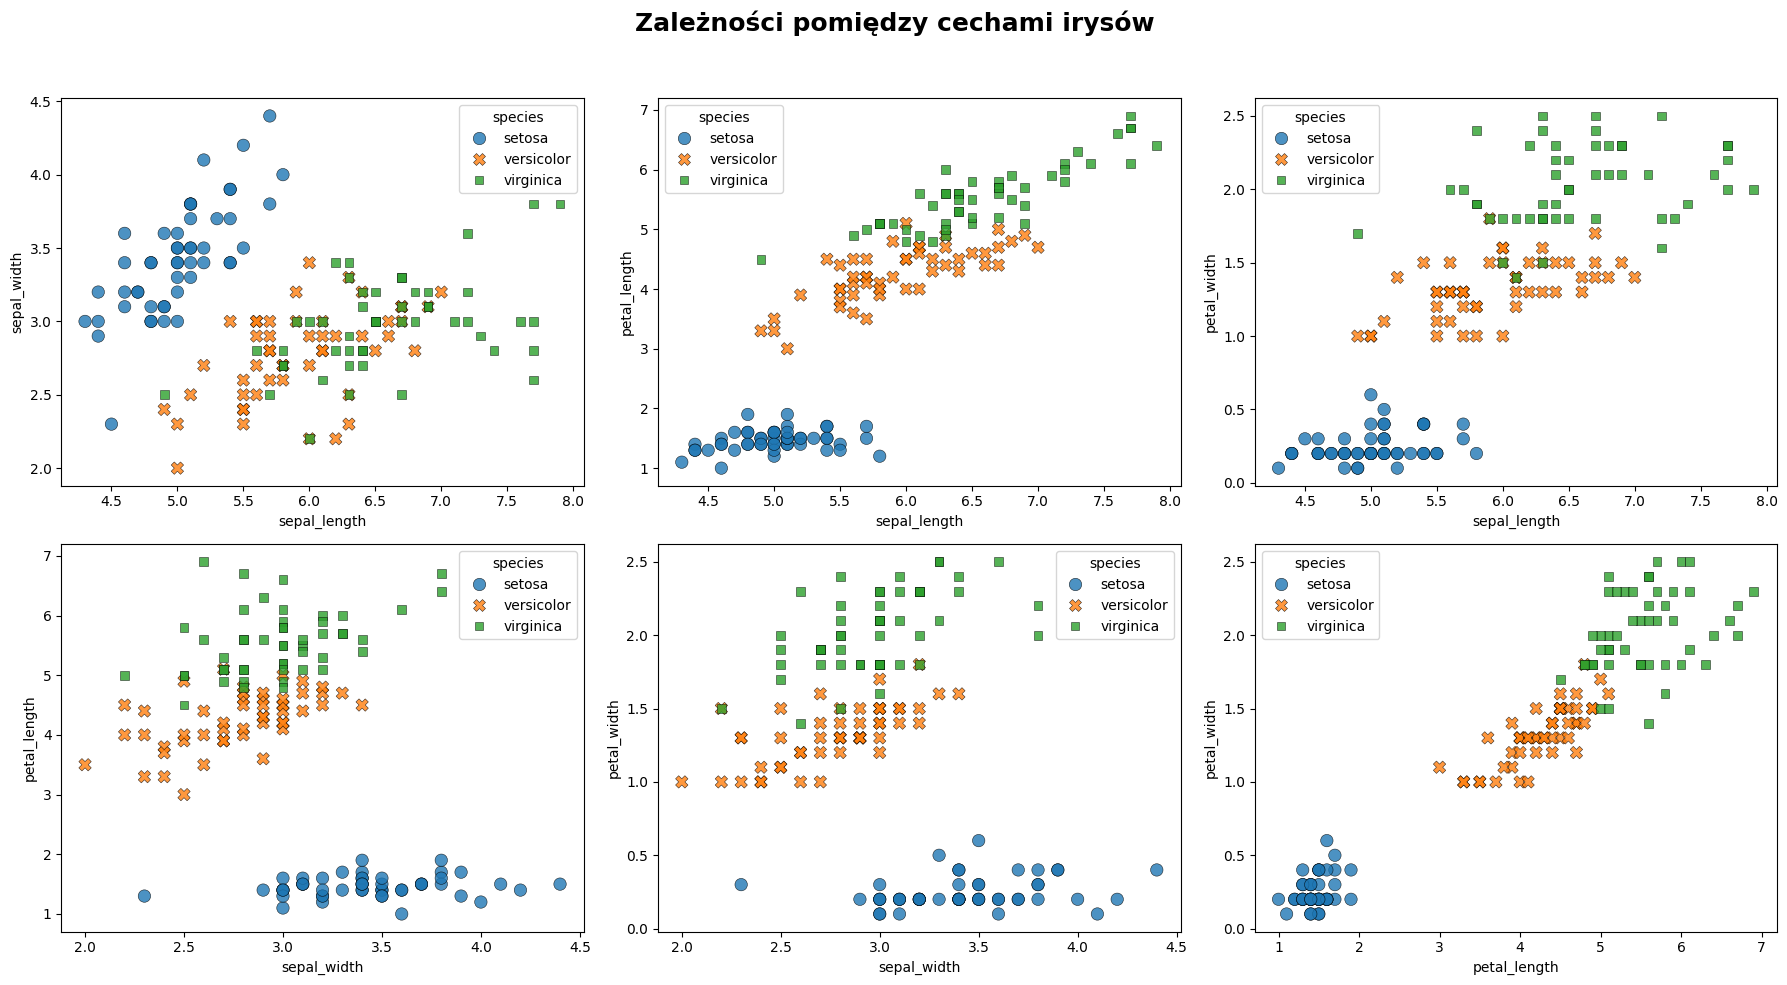

In [27]:
# Sekcja 3: Generowanie wykresów

# Pary cech, które będą ze sobą porównywane
feature_pairs = [
    # oś X              oś Y
    ("sepal_length", "sepal_width"),
    ("sepal_length", "petal_length"),
    ("sepal_length", "petal_width"),
    ("sepal_width", "petal_length"),
    ("sepal_width", "petal_width"),
    ("petal_length", "petal_width")
]

# Polskie nazwy cech
feature_names_pl = {
    "sepal_length": "Długość działki kielicha [cm]",
    "sepal_width": "Szerokość działki kielicha [cm]",
    "petal_length": "Długość płatka [cm]",
    "petal_width": "Szerokość płatka [cm]"
}




fig, osie = plt.subplots(2,3, figsize=(18,10))

for wykres, (cecha_x, cecha_y) in zip(osie.flatten(), feature_pairs):
  sns.scatterplot(
    data=dane,
    x=cecha_x,
    y=cecha_y,
    hue="species",
    style="species",
    s=80,
    alpha=0.8,
    edgecolor = "black",
    linewidth = 0.4,
    ax=wykres
  )



# Tytuł całej figury
fig.suptitle(
    "Zależności pomiędzy cechami irysów",
    fontsize=18,
    fontweight="bold"
)

# Poprawienie odstępów między wykresami
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()


feature_pairs = [
    # oś X              oś Y
    ("sepal_length", "sepal_width"),
    ("sepal_length", "petal_length"),
    ("sepal_length", "petal_width"),
    ("sepal_width", "petal_length"),
    ("sepal_width", "petal_width"),
    ("petal_length", "petal_width")
]

**PSEUDOKOD:**

```
Funkcja KNN(nowy_kwiat, dane_uczące, k):

    Dla każdego kwiatu w danych uczących:
       - Oblicz odległość euklidesową od nowego kwiatu
       - Zapisz odległość razem z gatunkiem

    Posortuj kwiaty od najbliższego do najdalszego

    Wybierz k najbliższych kwiatów

    Policz, ile razy występuje każdy gatunek

    Wybierz gatunek z największą liczbą głosów

    Zwróć przewidywany gatunek
```

In [28]:
#Sekcja  4: Przygotowanie danych dla algorytmu

x = dane.drop(columns="species")
y = dane["species"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    shuffle= True,
    stratify=y
)


# Informacje o podziale danych
print("\nPodział danych:")

print(
    f"Zbiór uczący: {len(x_train)} próbek "
    f"({len(x_train) / len(dane) * 100:.0f}%)"
)

print(
    f"Zbiór testowy: {len(x_test)} próbek "
    f"({len(x_test) / len(dane) * 100:.0f}%)"
)

# Rozkład gatunków w zbiorze uczącym
print("\nGatunki w zbiorze uczącym:")

for gatunek, liczba in y_train.value_counts().sort_index().items():
    print(f"{gatunek}: {liczba} próbek")

# Rozkład gatunków w zbiorze testowym
print("\nGatunki w zbiorze testowym:")

for gatunek, liczba in y_test.value_counts().sort_index().items():
    print(f"{gatunek}: {liczba} próbek")


Podział danych:
Zbiór uczący: 120 próbek (80%)
Zbiór testowy: 30 próbek (20%)

Gatunki w zbiorze uczącym:
setosa: 40 próbek
versicolor: 40 próbek
virginica: 40 próbek

Gatunki w zbiorze testowym:
setosa: 10 próbek
versicolor: 10 próbek
virginica: 10 próbek


In [29]:
#Sekcja 5: Implementacja algorytmu KNN

def calculate_distance(point1, point2):
    distance = 0

    for v1, v2 in zip(point1, point2):
      distance += (v1 - v2) ** 2

    return np.sqrt(distance)




def knn_classifier(x_train, y_train, x_test, k):
  x_train = np.asarray(x_train)
  y_train = np.asarray(y_train)
  x_test = np.asarray(x_test)

  predictions = []

  for test_point in x_test:
    distances = []


    for train_point, label in zip(x_train, y_train):
      distance = calculate_distance(test_point, train_point)

      distances.append((distance, label))

    # sortowanie
    distances.sort(key=lambda element: element[0])

    neighbors = distances[:k]

    votes = {}

    for _, label in neighbors:
      votes[label] = votes.get(label, 0) + 1


    most_common_label = max(votes, key=votes.get)

    predictions.append(most_common_label)

  return predictions



In [30]:
# Sekcja 6: Testowanie algorytmu KNN

def test_KNN(k):
    predictions = knn_classifier(x_train, y_train, x_test, k)

    predictions = np.array(predictions)
    actual = np.array(y_test)

    print(f"\nWyniki dla k = {k}:")

    for i, (prediction, real) in enumerate(zip(predictions, actual), start=1):
        print(f"Próbka {i}: predykcja = {prediction}, rzeczywisty = {real}")

    accuracy = np.mean(predictions == actual)

    print(f"\nDokładność algorytmu KNN dla k = {k}: {accuracy:.2f}")

In [56]:
test_KNN(k=70)
#


Wyniki dla k = 70:
Próbka 1: predykcja = setosa, rzeczywisty = setosa
Próbka 2: predykcja = versicolor, rzeczywisty = virginica
Próbka 3: predykcja = versicolor, rzeczywisty = versicolor
Próbka 4: predykcja = versicolor, rzeczywisty = versicolor
Próbka 5: predykcja = setosa, rzeczywisty = setosa
Próbka 6: predykcja = versicolor, rzeczywisty = versicolor
Próbka 7: predykcja = setosa, rzeczywisty = setosa
Próbka 8: predykcja = setosa, rzeczywisty = setosa
Próbka 9: predykcja = virginica, rzeczywisty = virginica
Próbka 10: predykcja = versicolor, rzeczywisty = versicolor
Próbka 11: predykcja = virginica, rzeczywisty = virginica
Próbka 12: predykcja = virginica, rzeczywisty = virginica
Próbka 13: predykcja = virginica, rzeczywisty = virginica
Próbka 14: predykcja = versicolor, rzeczywisty = versicolor
Próbka 15: predykcja = setosa, rzeczywisty = setosa
Próbka 16: predykcja = setosa, rzeczywisty = setosa
Próbka 17: predykcja = setosa, rzeczywisty = setosa
Próbka 18: predykcja = versicolor,